In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/AI_ML_Projects 2026/Data/Student_Performance_Prediction/student_performance.csv")

df.head()

,Study_Hours,Attendance,Assignments,Quiz_Score,Exam_Marks
0,7,92,1,68,73
1,4,99,6,77,78
2,8,71,5,42,76
3,5,95,3,55,72
4,7,63,7,69,79


In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X = df[['Study_Hours', 'Attendance', 'Assignments', 'Quiz_Score']]

y = df['Exam_Marks']

In [5]:
X.head()

,Study_Hours,Attendance,Assignments,Quiz_Score
0,7,92,1,68
1,4,99,6,77
2,8,71,5,42
3,5,95,3,55
4,7,63,7,69


In [6]:
X.head()

,Study_Hours,Attendance,Assignments,Quiz_Score
0,7,92,1,68
1,4,99,6,77
2,8,71,5,42
3,5,95,3,55
4,7,63,7,69


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 4)
Testing Data: (200, 4)


In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [13]:
y_pred = model.predict(X_test)

In [14]:
print(y_pred[:10])

[ 78.29872522 100.45764913  54.48977777  84.84924974  90.00894925
  65.62909173  66.15355756  61.638696    92.28551484 102.67080042]


In [15]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [16]:
r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

In [17]:
print("R2 Score :", r2)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

R2 Score : 0.9556861399341178
MAE : 2.7439899237379346
MSE : 10.19656491668091
RMSE : 3.193206056094863


In [18]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Study_Hours,4.040967
1,Attendance,0.244308
2,Assignments,1.985852
3,Quiz_Score,0.339922


In [19]:
# Intercept print

In [20]:
print("Intercept:", model.intercept_)

Intercept: 1.0961815173348555


In [21]:
# Prediction vs Actual

In [23]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
521,75,78.298725
737,101,100.457649
740,51,54.489778
660,89,84.849250
411,94,90.008949
678,70,65.629092
626,65,66.153558
513,58,61.638696
859,89,92.285515
136,100,102.670800


In [25]:
# Prediction Error

In [24]:
comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

comparison.head(10)

,Actual,Predicted,Error
521,75,78.298725,-3.298725
737,101,100.457649,0.542351
740,51,54.489778,-3.489778
660,89,84.849250,4.150750
411,94,90.008949,3.991051
678,70,65.629092,4.370908
626,65,66.153558,-1.153558
513,58,61.638696,-3.638696
859,89,92.285515,-3.285515
136,100,102.670800,-2.670800


In [26]:
# Scatter Plot

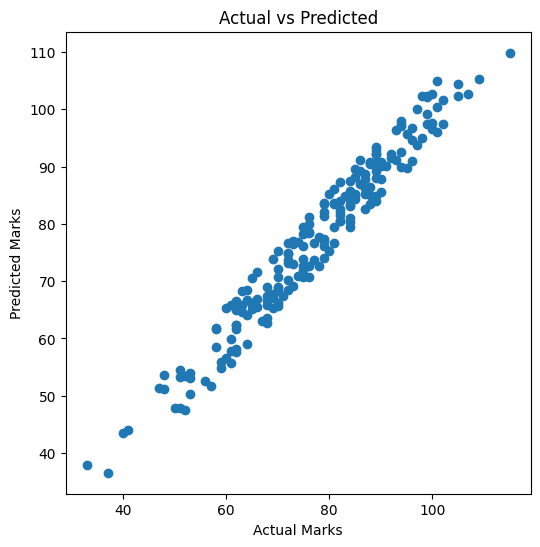

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")

plt.title("Actual vs Predicted")

plt.show()

In [29]:
# Residual Distribution

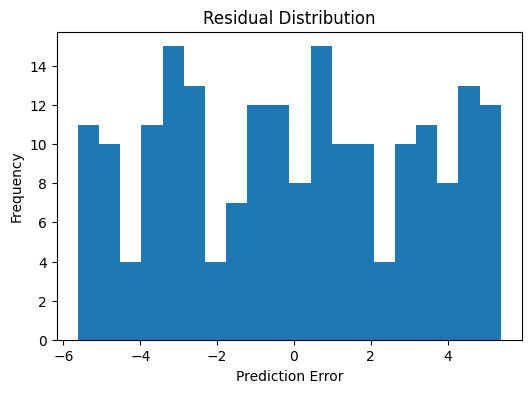

In [30]:
errors = y_test - y_pred

plt.figure(figsize=(6,4))

plt.hist(errors, bins=20)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()

In [31]:
import sklearn
print(sklearn.__version__)

1.6.1
